# Análise de Desempenho dos Algoritmos de Ordenação

Este notebook gera gráficos dinâmicos a partir do CSV produzido pelo projeto Java.

Algoritmos analisados:

- Bubble Sort
- Selection Sort
- Merge Sort
- Quick Sort

Cada algoritmo possui versão serial e versão paralela.

In [1]:
# Caso necessário, instale as bibliotecas:
# !pip install pandas plotly ipywidgets

import pandas as pd
import plotly.express as px
from pathlib import Path

## 1. Carregar CSV

Por padrão, o Java salva o resultado em `out/resultados_ordenacao.csv`.

In [2]:
csv_path = Path("out/resultados_ordenacao.csv")

if not csv_path.exists():
    raise FileNotFoundError(
        "Arquivo out/resultados_ordenacao.csv não encontrado. "
        "Execute primeiro o projeto Java para gerar o CSV."
    )

df = pd.read_csv(csv_path)
df.head()

,algorithm,base_algorithm,execution_type,threads,size,data_type,sample,time_ns,time_ms,sorted
0,BubbleSortSerial,BubbleSort,SERIAL,1,1000,RANDOM,1,5867469,5.867469,True
1,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,RANDOM,1,19215934,19.215934,True
2,BubbleSortParallel,BubbleSort,PARALLEL,4,1000,RANDOM,1,15658567,15.658567,True
3,BubbleSortParallel,BubbleSort,PARALLEL,8,1000,RANDOM,1,25156377,25.156377,True
4,BubbleSortParallel,BubbleSort,PARALLEL,16,1000,RANDOM,1,68371935,68.371935,True


## 2. Conferir estrutura dos dados

In [3]:
print("Total de linhas:", len(df))
print("Colunas:", list(df.columns))
print("\nAlgoritmos:")
print(df["algorithm"].unique())
print("\nAlgoritmos base:")
print(df["base_algorithm"].unique())
print("\nTipos de dados:")
print(df["data_type"].unique())
print("\nThreads:")
print(sorted(df["threads"].unique()))

Total de linhas: 1600
Colunas: ['algorithm', 'base_algorithm', 'execution_type', 'threads', 'size', 'data_type', 'sample', 'time_ns', 'time_ms', 'sorted']

Algoritmos:
<StringArray>
[     'BubbleSortSerial',    'BubbleSortParallel',   'SelectionSortSerial',
 'SelectionSortParallel',       'MergeSortSerial',     'MergeSortParallel',
       'QuickSortSerial',     'QuickSortParallel']
Length: 8, dtype: str

Algoritmos base:
<StringArray>
['BubbleSort', 'SelectionSort', 'MergeSort', 'QuickSort']
Length: 4, dtype: str

Tipos de dados:
<StringArray>
['RANDOM', 'SORTED', 'REVERSED', 'NEARLY_SORTED']
Length: 4, dtype: str

Threads:
[np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16)]


## 3. Estatísticas: média, desvio padrão e amostras

In [4]:
summary = (
    df.groupby(["algorithm", "base_algorithm", "execution_type", "threads", "size", "data_type"], as_index=False)
      .agg(
          mean_time_ms=("time_ms", "mean"),
          std_time_ms=("time_ms", "std"),
          samples=("time_ms", "count")
      )
)

summary.head()

,algorithm,base_algorithm,execution_type,threads,size,data_type,mean_time_ms,std_time_ms,samples
0,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,NEARLY_SORTED,7.099656,1.018387,5
1,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,RANDOM,7.488344,6.600402,5
2,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,REVERSED,6.043121,1.948822,5
3,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,SORTED,6.879959,1.720618,5
4,BubbleSortParallel,BubbleSort,PARALLEL,2,2000,NEARLY_SORTED,15.025763,6.260919,5


## 4. Tempo médio geral por algoritmo

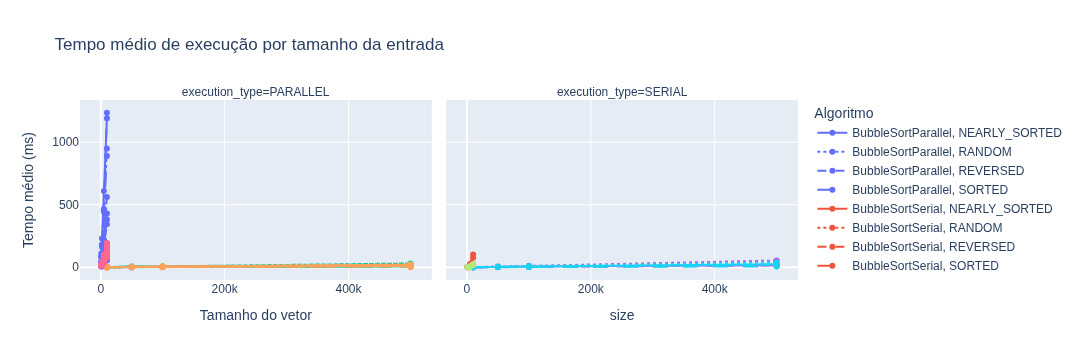

In [5]:
fig = px.line(
    summary,
    x="size",
    y="mean_time_ms",
    color="algorithm",
    line_dash="data_type",
    facet_col="execution_type",
    markers=True,
    hover_data=["threads", "std_time_ms", "samples"],
    title="Tempo médio de execução por tamanho da entrada"
)

fig.update_layout(
    xaxis_title="Tamanho do vetor",
    yaxis_title="Tempo médio (ms)",
    legend_title="Algoritmo"
)

fig.show()

## 5. Comparação por tipo de entrada

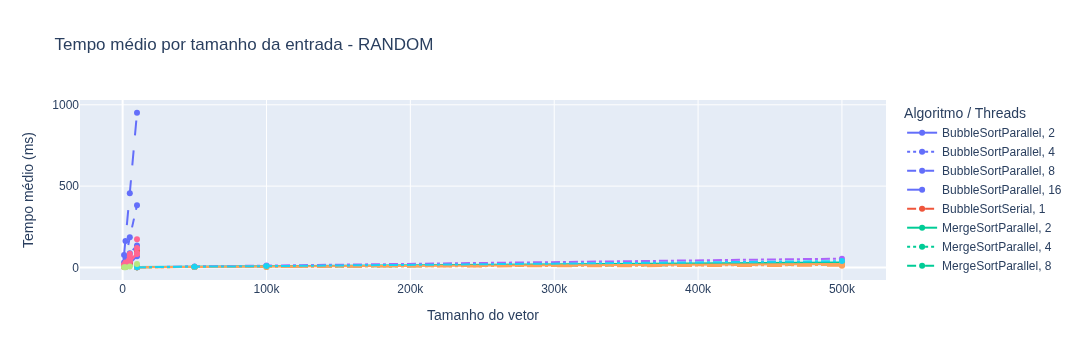

In [6]:
tipo_entrada = "RANDOM"

filtered = summary[summary["data_type"] == tipo_entrada]

fig = px.line(
    filtered,
    x="size",
    y="mean_time_ms",
    color="algorithm",
    line_dash="threads",
    markers=True,
    hover_data=["execution_type", "std_time_ms", "samples"],
    title=f"Tempo médio por tamanho da entrada - {tipo_entrada}"
)

fig.update_layout(
    xaxis_title="Tamanho do vetor",
    yaxis_title="Tempo médio (ms)",
    legend_title="Algoritmo / Threads"
)

fig.show()

## 6. Comparação apenas dos algoritmos paralelos

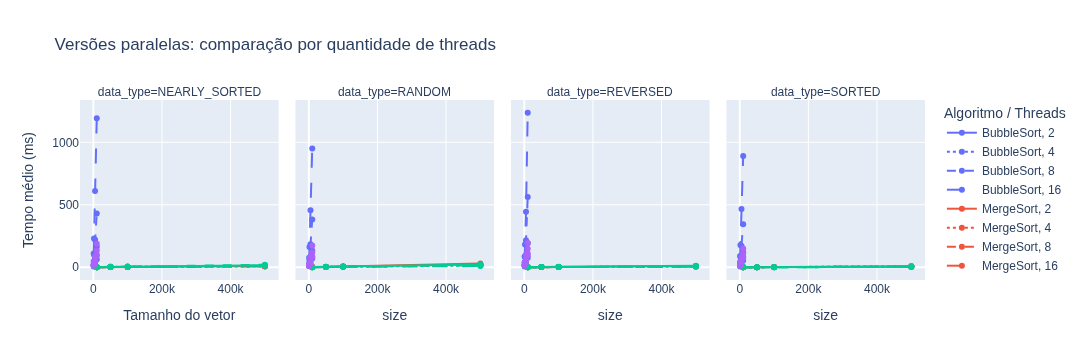

In [7]:
parallel = summary[summary["execution_type"] == "PARALLEL"]

fig = px.line(
    parallel,
    x="size",
    y="mean_time_ms",
    color="base_algorithm",
    line_dash="threads",
    facet_col="data_type",
    markers=True,
    hover_data=["algorithm", "std_time_ms", "samples"],
    title="Versões paralelas: comparação por quantidade de threads"
)

fig.update_layout(
    xaxis_title="Tamanho do vetor",
    yaxis_title="Tempo médio (ms)",
    legend_title="Algoritmo / Threads"
)

fig.show()

## 7. Comparação por algoritmo específico

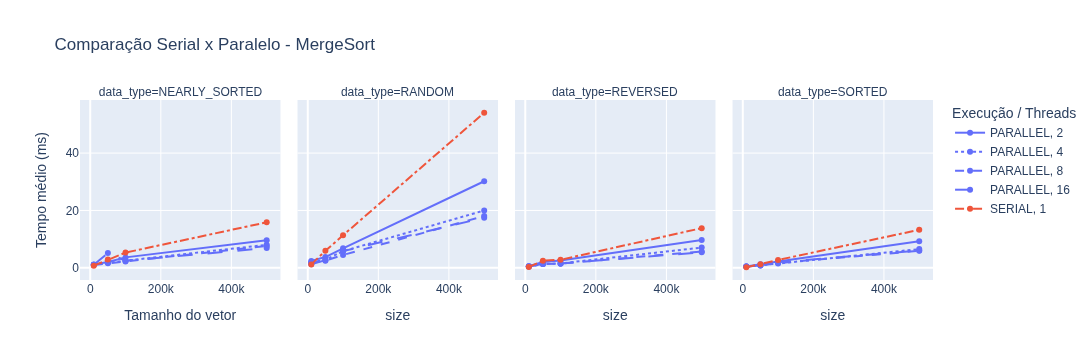

In [8]:
algoritmo = "MergeSort"  # Opções: BubbleSort, SelectionSort, MergeSort, QuickSort

alg_df = summary[summary["base_algorithm"] == algoritmo]

fig = px.line(
    alg_df,
    x="size",
    y="mean_time_ms",
    color="execution_type",
    line_dash="threads",
    facet_col="data_type",
    markers=True,
    hover_data=["algorithm", "std_time_ms", "samples"],
    title=f"Comparação Serial x Paralelo - {algoritmo}"
)

fig.update_layout(
    xaxis_title="Tamanho do vetor",
    yaxis_title="Tempo médio (ms)",
    legend_title="Execução / Threads"
)

fig.show()

## 8. Cálculo de Speedup

Speedup:

\[
Speedup = \frac{Tempo\ Serial}{Tempo\ Paralelo}
\]

Valores maiores que 1 indicam ganho de desempenho.

In [9]:
serial = summary[summary["execution_type"] == "SERIAL"].copy()
parallel = summary[summary["execution_type"] == "PARALLEL"].copy()

speedup = parallel.merge(
    serial[["base_algorithm", "size", "data_type", "mean_time_ms"]],
    on=["base_algorithm", "size", "data_type"],
    suffixes=("_parallel", "_serial")
)

speedup["speedup"] = speedup["mean_time_ms_serial"] / speedup["mean_time_ms_parallel"]
speedup["efficiency"] = speedup["speedup"] / speedup["threads"]

speedup.head()

,algorithm,base_algorithm,execution_type,threads,size,data_type,mean_time_ms_parallel,std_time_ms,samples,mean_time_ms_serial,speedup,efficiency
0,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,NEARLY_SORTED,7.099656,1.018387,5,0.330737,0.046585,0.023292
1,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,RANDOM,7.488344,6.600402,5,1.992172,0.266036,0.133018
2,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,REVERSED,6.043121,1.948822,5,1.320252,0.218472,0.109236
3,BubbleSortParallel,BubbleSort,PARALLEL,2,1000,SORTED,6.879959,1.720618,5,0.002719,0.000395,0.000198
4,BubbleSortParallel,BubbleSort,PARALLEL,2,2000,NEARLY_SORTED,15.025763,6.260919,5,1.358169,0.090389,0.045195


## 9. Gráfico de Speedup

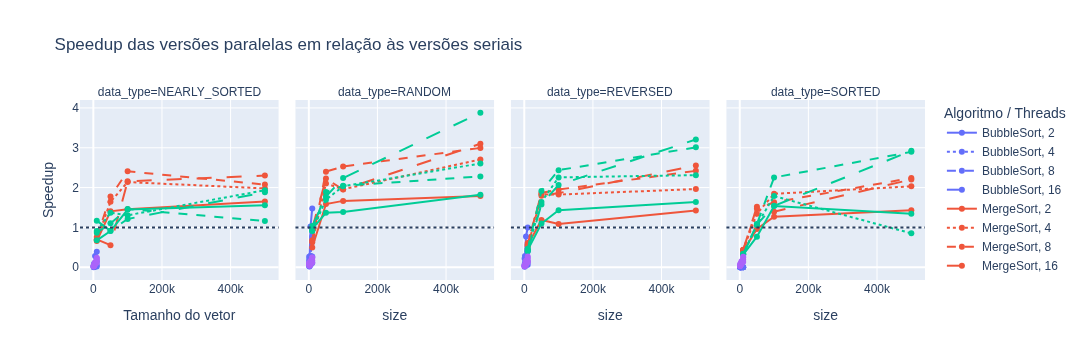

In [10]:
fig = px.line(
    speedup,
    x="size",
    y="speedup",
    color="base_algorithm",
    line_dash="threads",
    facet_col="data_type",
    markers=True,
    hover_data=["mean_time_ms_serial", "mean_time_ms_parallel", "efficiency"],
    title="Speedup das versões paralelas em relação às versões seriais"
)

fig.add_hline(y=1, line_dash="dot")

fig.update_layout(
    xaxis_title="Tamanho do vetor",
    yaxis_title="Speedup",
    legend_title="Algoritmo / Threads"
)

fig.show()

## 10. Gráfico de Eficiência Paralela

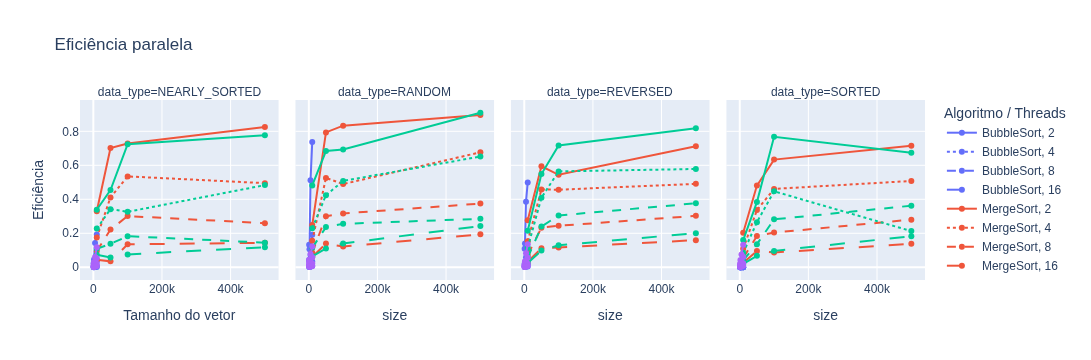

In [11]:
fig = px.line(
    speedup,
    x="size",
    y="efficiency",
    color="base_algorithm",
    line_dash="threads",
    facet_col="data_type",
    markers=True,
    hover_data=["speedup"],
    title="Eficiência paralela"
)

fig.update_layout(
    xaxis_title="Tamanho do vetor",
    yaxis_title="Eficiência",
    legend_title="Algoritmo / Threads"
)

fig.show()

## 11. Exportar tabelas resumidas

In [12]:
summary.to_csv("out/resumo_estatistico.csv", index=False)
speedup.to_csv("out/speedup_eficiencia.csv", index=False)

print("Arquivos gerados:")
print("- out/resumo_estatistico.csv")
print("- out/speedup_eficiencia.csv")

Arquivos gerados:
- out/resumo_estatistico.csv
- out/speedup_eficiencia.csv
